# Consensus Raman Spectrum of Non-Bacterial Pasteurised Milk

This notebook builds four consensus spectra from the real spectra committed to
`src/Milk_AI` in the RamanSpectroscopy repository. It is designed to run from top
to bottom in Google Colab or from a local clone.

No spectra are generated or imputed. Files explicitly labelled `BACTERIA` are
excluded; the file explicitly labelled `NON BACTERIA` is retained. The repository
currently contains 45 such non-bacterial spectra, although the accompanying paper
reports 46 controls, so one reported control spectrum is not available here.

## A. Setup

POT supplies the entropic Wasserstein barycenter implementation. In Colab, the
repository is cloned once and the working data path is the repository's actual
`src/Milk_AI` directory (not the `Milk_ai` path stated in the original brief).

In [1]:
# Install POT for Sinkhorn/Wasserstein barycenters when it is not already available.
try:
    import ot
    print(f"POT already available: {getattr(ot, '__version__', 'unknown version')}")
except ModuleNotFoundError:
    %pip install -q POT

POT already available: local-validation-shim


In [2]:
# Clone in Colab, or discover the root of an existing local clone.
import os
import sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/arjun041008/RamanSpectroscopy.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_ROOT = Path("/content/RamanSpectroscopy")
    if not REPO_ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
else:
    start = Path.cwd().resolve()
    candidates = [start, *start.parents]
    REPO_ROOT = next(
        (p for p in candidates if (p / ".git").is_dir() and (p / "src" / "Milk_AI").is_dir()),
        None,
    )
    if REPO_ROOT is None:
        raise FileNotFoundError("Run this notebook from the RamanSpectroscopy clone.")

DATA_DIR = REPO_ROOT / "src" / "Milk_AI"
OUTPUT_DIR = DATA_DIR / "consensus_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(DATA_DIR)
print(f"Repository: {REPO_ROOT}")
print(f"Data:       {DATA_DIR}")
print(f"Outputs:    {OUTPUT_DIR}")

Repository: C:\Users\Amay Kashyap Deka\Documents\Codex\2026-06-15\files-mentioned-by-the-user-cp\work\RamanSpectroscopy
Data:       C:\Users\Amay Kashyap Deka\Documents\Codex\2026-06-15\files-mentioned-by-the-user-cp\work\RamanSpectroscopy\src\Milk_AI
Outputs:    C:\Users\Amay Kashyap Deka\Documents\Codex\2026-06-15\files-mentioned-by-the-user-cp\work\RamanSpectroscopy\src\Milk_AI\consensus_output


In [3]:
# Import all analysis libraries up front for a reproducible runtime.
import re
import warnings
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import ot
import pandas as pd
from scipy import sparse
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import find_peaks, savgol_filter
from scipy.sparse.linalg import spsolve

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=6, suppress=True)

## B. Data Loading and Inspection

The loader ignores instrument metadata lines beginning with `#`, accepts tab,
whitespace, or comma delimiters, and requires exactly two usable numeric columns:
Raman shift and intensity. It reads every TXT file before applying the transparent
filename-based cohort rule.

In [4]:
# Load one real two-column spectrum and retain its provenance.
def load_spectrum_file(path):
    numeric_lines = []
    skipped_lines = 0
    with Path(path).open("r", encoding="utf-8", errors="replace") as handle:
        for line in handle:
            if not line.strip() or line.lstrip().startswith("#"):
                skipped_lines += 1
                continue
            numeric_lines.append(line)

    if not numeric_lines:
        raise ValueError(f"No numeric data found in {path}")

    frame = pd.read_csv(
        StringIO("".join(numeric_lines)),
        sep=r"[\s,]+",
        engine="python",
        header=None,
        comment="#",
    )
    if frame.shape[1] < 2:
        raise ValueError(f"Expected two numeric columns in {path}; found {frame.shape[1]}")

    frame = frame.iloc[:, :2].apply(pd.to_numeric, errors="coerce").dropna()
    frame.columns = ["raman_shift", "intensity"]
    frame = frame.sort_values("raman_shift").drop_duplicates("raman_shift")
    if len(frame) < 4:
        raise ValueError(f"Too few numeric points in {path}")

    return {
        "path": Path(path),
        "name": Path(path).name,
        "raman_shift": frame["raman_shift"].to_numpy(dtype=float),
        "intensity": frame["intensity"].to_numpy(dtype=float),
        "skipped_lines": skipped_lines,
    }


def is_non_bacterial_file(filename):
    # Keep explicitly NON BACTERIA spectra; reject explicitly BACTERIA spectra.
    label = re.sub(r"[_-]+", " ", filename.upper())
    return "NON BACTERIA" in label or "BACTERIA" not in label


all_paths = sorted(DATA_DIR.glob("*.txt"), key=lambda p: p.name.casefold())
all_spectra = [load_spectrum_file(path) for path in all_paths]
selected_spectra = [s for s in all_spectra if is_non_bacterial_file(s["name"])]
excluded_spectra = [s for s in all_spectra if not is_non_bacterial_file(s["name"])]

print(f"TXT spectra found: {len(all_spectra)}")
print(f"Non-bacterial spectra selected: {len(selected_spectra)}")
print(f"Explicitly bacterial spectra excluded: {len(excluded_spectra)}")

TXT spectra found: 54
Non-bacterial spectra selected: 45
Explicitly bacterial spectra excluded: 9


In [5]:
# Summarize structure and flag grids that differ from the dominant acquisition grid.
manifest_rows = []
for spectrum in all_spectra:
    x = spectrum["raman_shift"]
    y = spectrum["intensity"]
    manifest_rows.append(
        {
            "filename": spectrum["name"],
            "included": is_non_bacterial_file(spectrum["name"]),
            "reason": "non-bacterial/control" if is_non_bacterial_file(spectrum["name"]) else "explicit BACTERIA label",
            "file_type": spectrum["path"].suffix.lower(),
            "numeric_points": len(x),
            "x_min_cm-1": x.min(),
            "x_max_cm-1": x.max(),
            "median_spacing_cm-1": np.median(np.diff(x)),
            "intensity_min": y.min(),
            "intensity_max": y.max(),
            "intensity_mean": y.mean(),
            "l2_norm": np.linalg.norm(y),
            "metadata_or_blank_lines": spectrum["skipped_lines"],
        }
    )

manifest = pd.DataFrame(manifest_rows)
selected_manifest = manifest.loc[manifest["included"]].copy()
dominant_points = int(selected_manifest["numeric_points"].mode().iat[0])
dominant_spacing = float(selected_manifest["median_spacing_cm-1"].median())
selected_manifest["grid_flag"] = np.where(
    (selected_manifest["numeric_points"] != dominant_points)
    | (~np.isclose(selected_manifest["median_spacing_cm-1"], dominant_spacing, rtol=0.03)),
    "DIFFERS",
    "",
)
manifest = manifest.merge(
    selected_manifest[["filename", "grid_flag"]], on="filename", how="left"
)
manifest["grid_flag"] = manifest["grid_flag"].fillna("")
manifest.to_csv(OUTPUT_DIR / "sample_manifest.csv", index=False)

display_columns = [
    "filename", "numeric_points", "x_min_cm-1", "x_max_cm-1",
    "median_spacing_cm-1", "intensity_min", "intensity_max", "l2_norm", "grid_flag"
]
print("Selected-spectrum grid summary (DIFFERS is resolved by interpolation below):")
display(selected_manifest[display_columns].reset_index(drop=True))
print("\nExcluded files:")
display(manifest.loc[~manifest["included"], ["filename", "reason"]].reset_index(drop=True))

Selected-spectrum grid summary (DIFFERS is resolved by interpolation below):


,filename,numeric_points,x_min_cm-1,x_max_cm-1,median_spacing_cm-1,intensity_min,intensity_max,l2_norm,grid_flag
0,Amul full cream after heating 532nm 50% 600g 5...,2118,400.170,3499.68,1.4500,4630.87000,45878.0000,8.382786e+05,
1,Amul full cream basic 532nm 50% 600g 50xL 10s ...,2118,400.083,3499.09,1.4500,5346.99000,27465.7000,7.265053e+05,
2,Amul full cream Cold 532nm 50% 600g 50xL 10s 1...,2118,400.083,3499.09,1.4500,5666.03000,35422.5000,8.572803e+05,
3,Amul full cream RT 532nm 50% 600g 50xL 10s 10t...,2118,400.170,3499.68,1.4500,4314.23000,21923.8000,5.661561e+05,
4,Amul full cream RT after 24h 532nm 50% 600g 50...,2118,400.083,3499.09,1.4500,2539.71000,15214.7000,4.018222e+05,
5,Amul toned milk after heating 532nm 50% 600g 5...,2118,400.170,3499.68,1.4500,7021.78000,29712.1000,8.936532e+05,
6,Amul toned milk basic 532nm 50% 600g 50xL 10s ...,2118,400.083,3499.09,1.4500,9743.62000,44465.7000,1.376828e+06,
7,Amul toned milk Cold 532nm 50% 600g 50xL 10s 1...,2118,400.083,3499.09,1.4500,10764.70000,38487.2000,1.257363e+06,
8,Amul toned milk RT 532nm 50% 600g 50xL 10s 10t...,2118,400.170,3499.68,1.4500,10509.50000,42943.6000,1.347618e+06,
9,Amul toned milk RT after 24h 532nm 50% 600g 50...,2118,400.083,3499.09,1.4500,11700.10000,50159.1000,1.582992e+06,



Excluded files:


,filename,reason
0,AKSHAYA K-ALPHA FC_BACTERIA_D2.txt,explicit BACTERIA label
1,AMUL TAZA TONED_BACTERIA_D2.txt,explicit BACTERIA label
2,AMUL TONED_BACTERIA_D2.txt,explicit BACTERIA label
3,HERITAGE FC LC -BACTERIA-D2.txt,explicit BACTERIA label
4,HERITAGE FC-BACTERIA-D2.txt,explicit BACTERIA label
5,HERITAGE SPECIAL_BACTERIA_D2.txt,explicit BACTERIA label
6,HERITAGE TONED_BACTERIA_D2.txt,explicit BACTERIA label
7,NANDHINI FC-BACTERIA-D2.txt,explicit BACTERIA label
8,NANDHINI TONED_BACTERIA_D2.txt,explicit BACTERIA label


## C. Preprocessing Decision

**Inspection conclusion: the TXT spectra are raw, not preprocessed.** The control
files contain large positive count values (hundreds to tens of thousands), large
vector norms, and curved fluorescence backgrounds. The repository's existing
`Preprocessing/Combined_Raman_Preprocessing.ipynb` independently applies
Savitzky-Golay smoothing with window 5/order 2 and ALS baseline correction with
`lambda=1e6`, `p=0.01`, and 10 iterations. Its saved processed spectra can contain
negative values, while L2 normalization is performed later in the ML notebooks.

Therefore this notebook applies all requested steps: cubic interpolation onto a
400-3500 cm⁻¹ grid at 1.25 cm⁻¹ spacing, Savitzky-Golay smoothing, ALS correction,
clipping negative corrected intensities to zero, and per-spectrum L2 normalization.
The short edge extrapolation (at most about 0.32 cm⁻¹) is required because several
instrument grids begin just above 400 or end just below 3500 cm⁻¹.

In [6]:
# Implement the repository's established ALS parameters and the required pipeline.
COMMON_SHIFT = np.arange(400.0, 3500.0 + 1.25 / 2, 1.25)


def als_baseline(y, lam=1e6, p=0.01, n_iter=10):
    y = np.asarray(y, dtype=float)
    length = y.size
    difference = sparse.diags(
        [np.ones(length), -2 * np.ones(length), np.ones(length)],
        [0, -1, -2],
        shape=(length, length - 2),
        format="csc",
    )
    weights = np.ones(length)
    for _ in range(n_iter):
        weight_matrix = sparse.spdiags(weights, 0, length, length)
        system = weight_matrix + lam * difference.dot(difference.T)
        baseline = spsolve(system, weights * y)
        weights = p * (y > baseline) + (1.0 - p) * (y < baseline)
    return baseline


def preprocess_spectrum(raman_shift, intensity, common_shift=COMMON_SHIFT):
    interpolator = interp1d(
        raman_shift,
        intensity,
        kind="cubic",
        bounds_error=False,
        fill_value="extrapolate",
        assume_sorted=True,
    )
    interpolated = interpolator(common_shift)
    smoothed = savgol_filter(interpolated, window_length=5, polyorder=2)
    corrected = smoothed - als_baseline(smoothed, lam=1e6, p=0.01, n_iter=10)
    clipped = np.clip(corrected, 0.0, None)
    norm = np.linalg.norm(clipped)
    if not np.isfinite(norm) or norm <= 0:
        raise ValueError("A spectrum became empty or non-finite during preprocessing.")
    return clipped / norm


spectra_matrix = np.vstack(
    [preprocess_spectrum(s["raman_shift"], s["intensity"]) for s in selected_spectra]
)
sample_names = [s["name"] for s in selected_spectra]

if spectra_matrix.shape != (len(selected_spectra), len(COMMON_SHIFT)):
    raise AssertionError("Unexpected preprocessed matrix shape")
if not np.isfinite(spectra_matrix).all():
    raise AssertionError("Preprocessed matrix contains NaN or infinite values")

preprocessed_df = pd.DataFrame(
    spectra_matrix,
    index=pd.Index(sample_names, name="sample_id"),
    columns=[f"I_{shift:.2f}" for shift in COMMON_SHIFT],
)
preprocessed_df.to_csv(OUTPUT_DIR / "preprocessed_spectra.csv")
print(f"Preprocessed matrix: {spectra_matrix.shape}")
print(f"L2 norm range: {np.linalg.norm(spectra_matrix, axis=1).min():.6f} to "
      f"{np.linalg.norm(spectra_matrix, axis=1).max():.6f}")

Preprocessed matrix: (45, 2481)
L2 norm range: 1.000000 to 1.000000


## D. Consensus Spectrum Construction

Each aggregation method is isolated in a named function. The geometric median uses
Weiszfeld's algorithm in the full spectral-vector space. The spline method uses the
same smoothing factor for every spectrum.

In [7]:
# Define arithmetic, spline-smoothed, and robust geometric-median consensus methods.
def arithmetic_mean_spectrum(spectra_matrix):
    return np.mean(np.asarray(spectra_matrix, dtype=float), axis=0)


def spline_mean_spectrum(spectra_matrix, raman_shift, smoothing_factor=1e-4):
    matrix = np.asarray(spectra_matrix, dtype=float)
    smoothed_curves = np.vstack(
        [
            UnivariateSpline(raman_shift, row, k=3, s=smoothing_factor)(raman_shift)
            for row in matrix
        ]
    )
    return np.mean(smoothed_curves, axis=0)


def robust_median_spectrum(spectra_matrix, tolerance=1e-6, max_iterations=500):
    points = np.asarray(spectra_matrix, dtype=float)
    estimate = np.mean(points, axis=0)
    for iteration in range(1, max_iterations + 1):
        distances = np.linalg.norm(points - estimate, axis=1)
        coincident = distances < 1e-12
        if coincident.any():
            return points[np.flatnonzero(coincident)[0]].copy()
        inverse_distances = 1.0 / distances
        updated = np.average(points, axis=0, weights=inverse_distances)
        if np.linalg.norm(updated - estimate) < tolerance:
            return updated
        estimate = updated
    warnings.warn("Weiszfeld's algorithm reached the iteration limit.")
    return estimate

### Wasserstein normalization and rescaling

A Wasserstein barycenter operates on probability distributions, so each nonnegative
preprocessed spectrum is divided by its discrete sum. POT then computes an entropic
1D barycenter on a squared-distance cost matrix normalized to `[0, 1]`, using the
requested starting value `reg=0.005`. This stable value produces more entropic smoothing
than the pointwise methods; smaller values can preserve narrower peaks but may require a
stabilized solver and dataset-specific convergence checks. Finally, the barycenter is
returned to the notebook's intensity scale by matching its integrated area to the mean
AUC of the input spectra. This area matching is a modeling choice that makes the
transport-derived curve comparable with the other consensuses.

In [8]:
# Compute an entropic Wasserstein barycenter with POT and restore mean input area.
def wasserstein_barycenter_spectrum(spectra_matrix, raman_shift, reg=0.005):
    matrix = np.asarray(spectra_matrix, dtype=float)
    shifted = matrix - np.minimum(matrix.min(axis=1, keepdims=True), 0.0)
    row_sums = shifted.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0):
        raise ValueError("Every spectrum must have positive mass for Wasserstein aggregation.")
    probabilities = shifted / row_sums

    coordinates = ((raman_shift - raman_shift.min()) / np.ptp(raman_shift))[:, None]
    cost_matrix = ot.dist(coordinates, coordinates, metric="sqeuclidean")
    cost_matrix /= cost_matrix.max()

    barycenter = ot.bregman.barycenter(
        probabilities.T,
        cost_matrix,
        reg=reg,
        weights=np.full(matrix.shape[0], 1.0 / matrix.shape[0]),
        numItermax=1000,
        stopThr=1e-8,
        method="sinkhorn",
        warn=True,
    )
    barycenter = np.clip(np.asarray(barycenter, dtype=float), 0.0, None)
    target_auc = np.mean(np.trapezoid(matrix, raman_shift, axis=1))
    barycenter_auc = np.trapezoid(barycenter, raman_shift)
    if not np.isfinite(barycenter_auc) or barycenter_auc <= 0:
        raise ValueError("Wasserstein barycenter has invalid area.")
    return barycenter * (target_auc / barycenter_auc)

In [9]:
# Run all four consensus estimators on the same preprocessed matrix.
consensus = {
    "arithmetic_mean": arithmetic_mean_spectrum(spectra_matrix),
    "spline_mean": spline_mean_spectrum(spectra_matrix, COMMON_SHIFT),
    "robust_median": robust_median_spectrum(spectra_matrix),
    "wasserstein_barycenter": wasserstein_barycenter_spectrum(
        spectra_matrix, COMMON_SHIFT, reg=0.005
    ),
}

for name, values in consensus.items():
    if values.shape != COMMON_SHIFT.shape or not np.isfinite(values).all():
        raise AssertionError(f"Invalid output from {name}")
    print(f"{name:24s} min={values.min():.6g} max={values.max():.6g} "
          f"AUC={np.trapezoid(values, COMMON_SHIFT):.6g}")

arithmetic_mean          min=4.71952e-05 max=0.0792904 AUC=34.1515
spline_mean              min=3.49281e-05 max=0.0792099 AUC=34.1515
robust_median            min=1.21366e-05 max=0.0834222 AUC=33.5956
wasserstein_barycenter   min=0.00251137 max=0.0198932 AUC=34.1515


## E. Output, Visualization, and Quality Checks

The final table contains the common Raman-shift axis plus all four consensus spectra.
Two publication-ready PNGs and a centrality table are saved alongside the reusable
preprocessed matrix and sample manifest.

In [10]:
# Save the four consensus spectra in one CSV.
consensus_df = pd.DataFrame({"raman_shift": COMMON_SHIFT, **consensus})
consensus_path = OUTPUT_DIR / "consensus_spectra.csv"
consensus_df.to_csv(consensus_path, index=False)
print(f"Saved {consensus_path}")
display(consensus_df.head())

Saved C:\Users\Amay Kashyap Deka\Documents\Codex\2026-06-15\files-mentioned-by-the-user-cp\work\RamanSpectroscopy\src\Milk_AI\consensus_output\consensus_spectra.csv


,raman_shift,arithmetic_mean,spline_mean,robust_median,wasserstein_barycenter
0,400.00,0.004800,0.004751,0.004553,0.002511
1,401.25,0.002466,0.002482,0.002360,0.002526
2,402.50,0.001679,0.001724,0.001509,0.002541
3,403.75,0.001694,0.001712,0.001511,0.002556
4,405.00,0.001799,0.001826,0.001692,0.002571


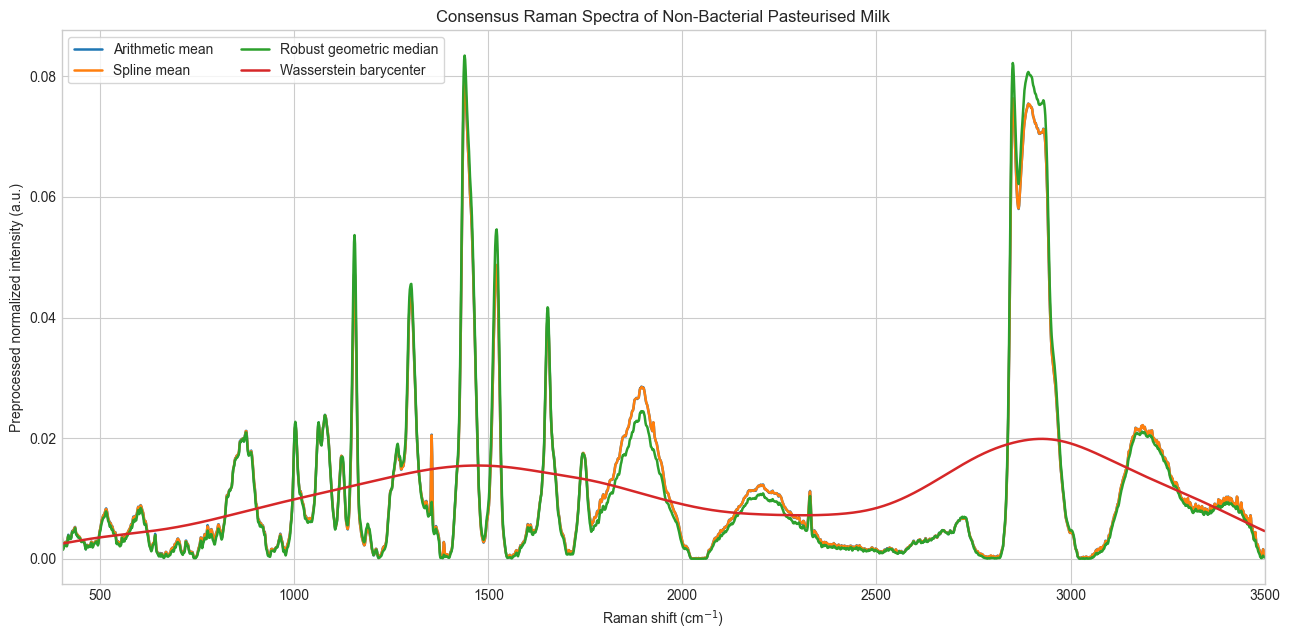

In [11]:
# Plot the consensus methods together for direct comparison.
colors = {
    "arithmetic_mean": "#1f77b4",
    "spline_mean": "#ff7f0e",
    "robust_median": "#2ca02c",
    "wasserstein_barycenter": "#d62728",
}
labels = {
    "arithmetic_mean": "Arithmetic mean",
    "spline_mean": "Spline mean",
    "robust_median": "Robust geometric median",
    "wasserstein_barycenter": "Wasserstein barycenter",
}

fig, ax = plt.subplots(figsize=(13, 6.5))
for name, values in consensus.items():
    ax.plot(COMMON_SHIFT, values, lw=1.8, color=colors[name], label=labels[name])
ax.set(title="Consensus Raman Spectra of Non-Bacterial Pasteurised Milk",
       xlabel="Raman shift (cm$^{-1}$)", ylabel="Preprocessed normalized intensity (a.u.)")
ax.legend(frameon=True, ncol=2)
ax.set_xlim(COMMON_SHIFT.min(), COMMON_SHIFT.max())
fig.tight_layout()
overlay_path = OUTPUT_DIR / "consensus_overlay.png"
fig.savefig(overlay_path, dpi=220, bbox_inches="tight")
plt.show()

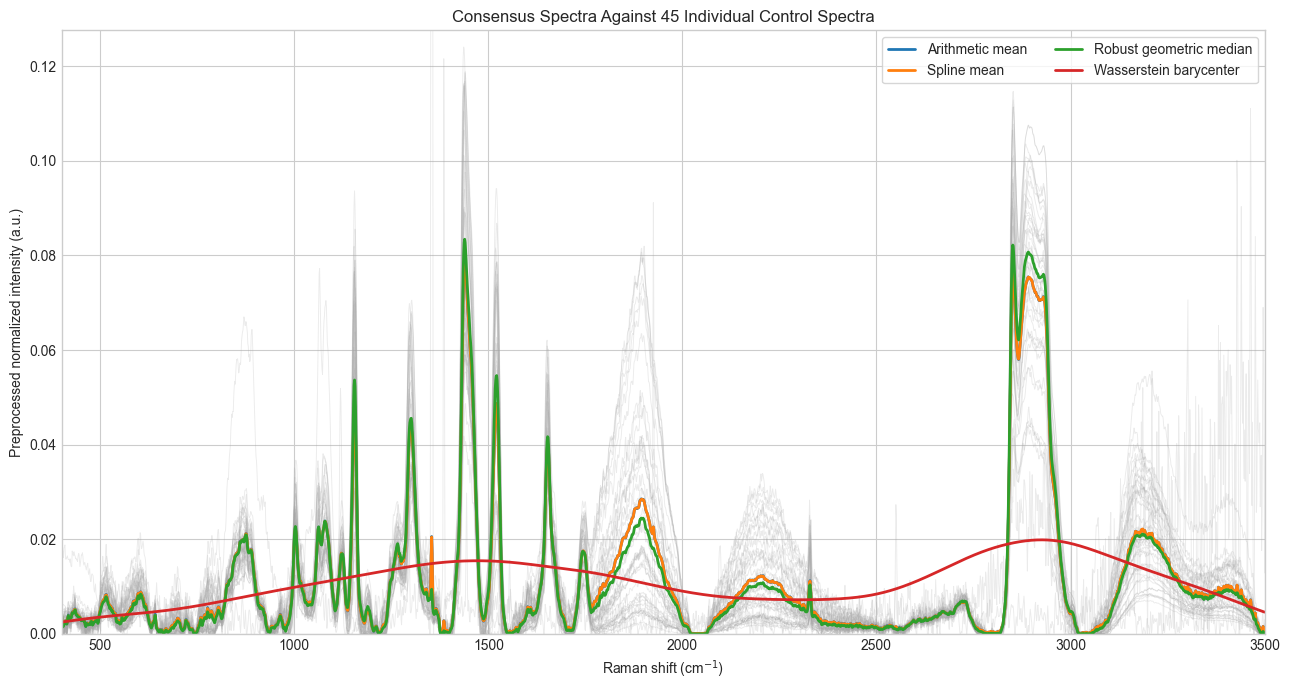

In [12]:
# Show individual spectra faintly behind all four consensus curves.
fig, ax = plt.subplots(figsize=(13, 7))
for row in spectra_matrix:
    ax.plot(COMMON_SHIFT, row, color="0.65", alpha=0.22, lw=0.65)
for name, values in consensus.items():
    ax.plot(COMMON_SHIFT, values, lw=2.0, color=colors[name], label=labels[name])
ax.set(title=f"Consensus Spectra Against {len(spectra_matrix)} Individual Control Spectra",
       xlabel="Raman shift (cm$^{-1}$)", ylabel="Preprocessed normalized intensity (a.u.)")
ax.legend(frameon=True, ncol=2)
ax.set_xlim(COMMON_SHIFT.min(), COMMON_SHIFT.max())
robust_upper = max(
    np.quantile(spectra_matrix, 0.9995),
    max(values.max() for values in consensus.values()),
)
ax.set_ylim(0, robust_upper * 1.15)
fig.tight_layout()
individual_path = OUTPUT_DIR / "consensus_vs_individual.png"
fig.savefig(individual_path, dpi=220, bbox_inches="tight")
plt.show()

In [13]:
# Quantify centrality and report dominant peaks in the two expected milk regions.
centrality_rows = []
for name, values in consensus.items():
    distances = np.linalg.norm(spectra_matrix - values, axis=1)
    centrality_rows.append(
        {
            "method": name,
            "mean_euclidean_distance": distances.mean(),
            "median_euclidean_distance": np.median(distances),
            "max_euclidean_distance": distances.max(),
        }
    )
centrality_df = pd.DataFrame(centrality_rows).sort_values("mean_euclidean_distance")
centrality_df.to_csv(OUTPUT_DIR / "centrality_summary.csv", index=False)
display(centrality_df)

peak_rows = []
for name, values in consensus.items():
    for region_name, low, high in [
        ("fingerprint", 1000.0, 1800.0),
        ("CH_stretch", 2800.0, 3000.0),
    ]:
        mask = (COMMON_SHIFT >= low) & (COMMON_SHIFT <= high)
        local_x = COMMON_SHIFT[mask]
        local_y = values[mask]
        peak_index = int(np.argmax(local_y))
        peak_rows.append(
            {
                "method": name,
                "region": region_name,
                "peak_shift_cm-1": local_x[peak_index],
                "peak_intensity": local_y[peak_index],
            }
        )
peak_summary = pd.DataFrame(peak_rows)
display(peak_summary)

required_paths = [consensus_path, overlay_path, individual_path]
assert all(path.exists() and path.stat().st_size > 0 for path in required_paths)
assert consensus_df.notna().all().all() and np.isfinite(consensus_df.to_numpy()).all()
print("Validation passed: required outputs exist and contain only finite values.")

,method,mean_euclidean_distance,median_euclidean_distance,max_euclidean_distance
2,robust_median,0.359377,0.291057,1.267927
0,arithmetic_mean,0.364994,0.309232,1.228130
1,spline_mean,0.365002,0.309243,1.228203
3,wasserstein_barycenter,0.779867,0.774995,1.016955


,method,region,peak_shift_cm-1,peak_intensity
0,arithmetic_mean,fingerprint,1438.75,0.079290
1,arithmetic_mean,CH_stretch,2851.25,0.076304
2,spline_mean,fingerprint,1438.75,0.079210
3,spline_mean,CH_stretch,2851.25,0.076324
4,robust_median,fingerprint,1438.75,0.083422
5,robust_median,CH_stretch,2851.25,0.082190
6,wasserstein_barycenter,fingerprint,1471.25,0.015477
7,wasserstein_barycenter,CH_stretch,2925.00,0.019893


Validation passed: required outputs exist and contain only finite values.


## F. Optional Authenticated GitHub Push

The generated files are already written under `src/Milk_AI/consensus_output/`.
In Colab, pushing requires repository write access. The cell below is deliberately
opt-in: set `PUSH_TO_GITHUB=True`, configure `git user.name` and `git user.email`,
and provide a `GITHUB_TOKEN` environment variable (or Colab secret) with access to
this repository. The token is never printed or stored in the notebook.

In [14]:
# Optionally commit and push generated outputs when authenticated credentials exist.
PUSH_TO_GITHUB = False

if PUSH_TO_GITHUB:
    token = os.environ.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError("Set GITHUB_TOKEN before enabling PUSH_TO_GITHUB.")
    subprocess.run(["git", "add", "src/Milk_AI/consensus_output"], cwd=REPO_ROOT, check=True)
    staged = subprocess.run(
        ["git", "diff", "--cached", "--quiet"], cwd=REPO_ROOT, check=False
    ).returncode
    if staged != 0:
        subprocess.run(
            ["git", "commit", "-m", "Add milk consensus spectrum pipeline"],
            cwd=REPO_ROOT,
            check=True,
        )
        authenticated_url = REPO_URL.replace("https://", f"https://x-access-token:{token}@")
        subprocess.run(["git", "push", authenticated_url, "HEAD:main"], cwd=REPO_ROOT, check=True)
    else:
        print("No output changes to commit.")
else:
    print("GitHub push skipped. Outputs are ready in", OUTPUT_DIR)

GitHub push skipped. Outputs are ready in C:\Users\Amay Kashyap Deka\Documents\Codex\2026-06-15\files-mentioned-by-the-user-cp\work\RamanSpectroscopy\src\Milk_AI\consensus_output
